## Math 178 Final Project (Winter 2026)

**Student Name:** Aparajita Bandopadhyay

**Student ID:** 52918931

------------------------------

In [ ]:
import sklearn
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import scipy

## **1) The Dataset**

We are using the
 [**Breast Cancer Wisconsin Dataset**](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) from the UC Irvine Machine Learning Repository.

 - This dataset contains `30` quantitative features (mainly spatial measurements) computed from scans of breast cancer tumors. The target variable for classification assumes the values: { `1: malginant`,`0:benign` }.
 - Our goal is to **classify tumors as "benign" or "malignant"** using 3 different classification models: **Logistic Regression,  Decision Trees, NN**.
  - Then we will compare the performance of these models across the metrics of Accuracy, Recall, MSE, and more.



In [ ]:
from sklearn.datasets import load_breast_cancer

#1) Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

#print("Dataset: ", df.head())
print(df.info())
#print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

In [ ]:
# Get the value counts for the 'target' column
print(df['target'].value_counts())
print(len(df))

target
1    357
0    212
Name: count, dtype: int64
569


## **2) Choosing and Training the Model.**


#### **2.1) Logistic Regression**



1. **We start by splitting the data into "train" and "test" sets.**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#1) Create df of features (X), containing all columns except 'target'.
X = df.drop('target', axis=1)

#2) Create df of target (Y), column of labels: "1" or "0".
y = df['target']

#3) Train/test split : 80% for train, 20% for test.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 4) Scale data into z-scores to help Logistic Regression converge
# z = (x - mu)/std.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

2. Now we **fit a logistic regression model to the data**, using all 30 feature columns, to predict the output label `y`.

In [ ]:
from sklearn.linear_model import LogisticRegression

# Initialize logreg object
logreg = LogisticRegression(max_iter=500)

# fit the model on scaled data
logreg.fit(X_train, y_train)

LogisticRegression(max_iter=500)

*Notes:*
1. Simple Logistic Regression failed to converge even after increasing max_iter to 1000.
2. To make it converge, we Scaled/standardized the data, after which it converged within just 500 iterations.


---



**3. Predict Labels on the Test dataset.**

In [ ]:
y_pred = logreg.predict(X_test)

**4. Assess Accuracy and Other Metrics.**

In [ ]:
# Accuracy : %(correctly predicted labels)
accuracy = logreg.score(X_test, y_test)
print(f"Accuracy: {accuracy * 100:.2f}%")

Accuracy: 97.37%


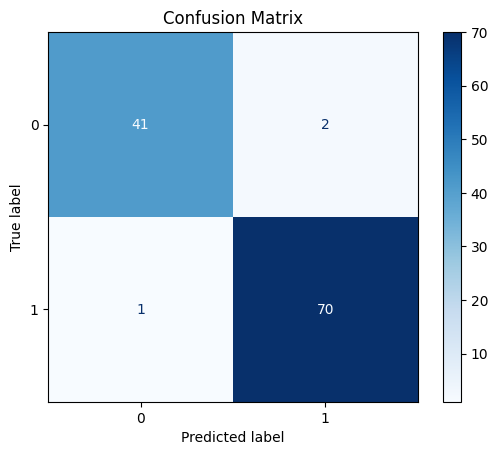

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [ ]:
#confusion matrix.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()

# report:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

1. Recall:
$$\frac{TP}{TP+FN} = P(\hat{Y} = 1|Y=1)$$

2. False Negative Rate:
$$ P(\hat{Y} = 0 | Y=1 ) = 1 - \text{Recall}$$

3. Precision:
$$P(Y=1| \hat{Y}=1) = \frac{TP}{TP+FP}$$

4. F-1 score:

$$F_1 = \frac{2TP}{2TP + FP + FN}$$

**Evaluation**
1. Logistic Regression provides excellent accuracy (97.37%) and recall (99%).
2. in this scenario, the risk of predicting *false negatives* is far greater than that of *false positives*.
- With logistic regression, the probability of a false negative (in this experiment) is only 1%.


---



### **2.2) PCA**

- The original Breast Cancer Wisconsin dataset contains `n=30` features.
We will use Principal Component Analysis to iteratively reduce the number of dimensions used in our analysis, with `n = 1, 2, ..., 5`.
- PCA works by computing the first $n$ **principal component vectors** of a data matrix. These PC vectors provide the directions of maximum variance within the feature space.
- After using PCA to form a set of `n` new transformed features (the PC vectors), we will fit a logistic regression to our tranformed dataset to predict the target variable (benign/malignant).
- We will store `accuracy` and `recall` metrics for each iteration (involving `n` features) in a list.
- We will compare model performance across number of features used, and identify the optimal number of features (providing maximum accuracy).

In [ ]:
from sklearn.metrics import accuracy_score, recall_score
from sklearn.decomposition import PCA

# create results_dict, an array of dictionaries : {"n":, "accuracy": , "recall":, ;}
results_dict = []

# Iterate through components
for n in range(1,6):
    # 1) Instantiate PCA object with n components
    pca = PCA(n_components=n)

    # 2) Transform X_train into n-dimensional dataset
    X_train_pca = pca.fit_transform(X_train)

    # 3) Transform X_test into n-dimensional dataset
    X_test_pca = pca.transform(X_test)

    # 4) Fit Logistic Regression model to X_train_pca, y_train
    model = LogisticRegression(max_iter=500)
    model.fit(X_train_pca, y_train)

    # 5) Generate predictions on X_test and store in y_pred
    y_pred = model.predict(X_test_pca)

    # 6) Compute accuracy (%correctly predicted labels) and recall
    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred, pos_label=1)

    #Store accuracy,recall in dictionary and append to results
    results_dict.append({'n_components': n, 'accuracy': acc, 'recall': rec})

#7) display:
for i in results_dict:
  print(i)

{'n_components': 1, 'accuracy': 0.9473684210526315, 'recall': 0.9859154929577465}
{'n_components': 2, 'accuracy': 0.9912280701754386, 'recall': 1.0}
{'n_components': 3, 'accuracy': 0.9824561403508771, 'recall': 1.0}
{'n_components': 4, 'accuracy': 0.9736842105263158, 'recall': 0.9859154929577465}
{'n_components': 5, 'accuracy': 0.9824561403508771, 'recall': 0.9859154929577465}


2. **Identify optimal number of components**

- We identify the number of components $n$ which provides the greatest predictive accuracy.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Identify optimal n_components for highest accuracy
optimal_result = max(results_dict, key=lambda x: x['accuracy'])

# display
print(f"Optimal number of components: {optimal_result['n_components']}")
print(f"Highest Accuracy achieved: {optimal_result['accuracy']:.4f}")

Optimal number of components: 2
Highest Accuracy achieved: 0.9912


3. **Draw a line plot of model performance (Accuracy vs. number of dimensions)**

We visualize how the model's accuracy changes with an increase in the number of principal component vectors used for prediction.

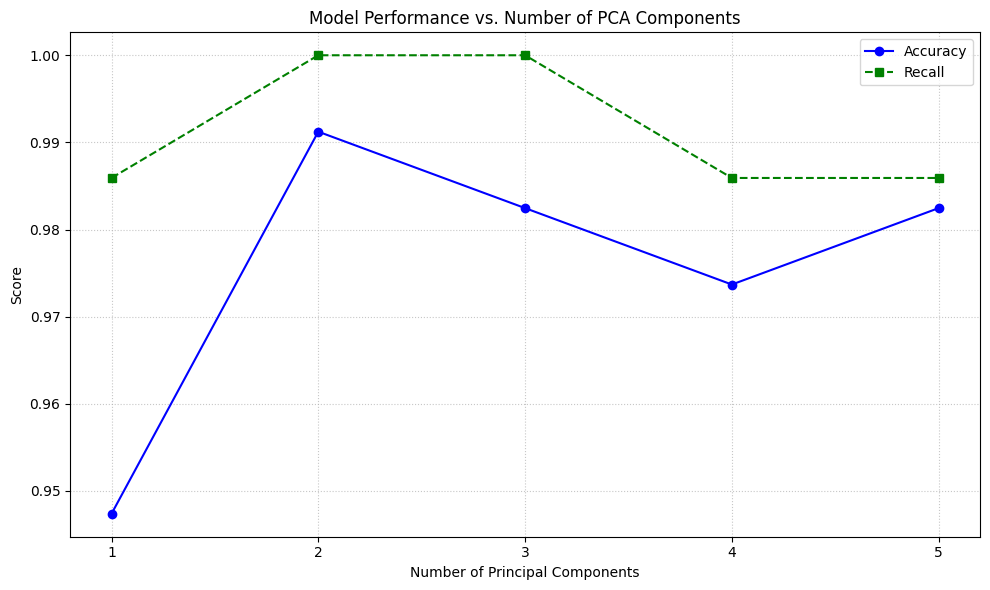

In [ ]:
# 1) Extract data for plotting
ns = [r['n_components'] for r in results_dict]
accs = [r['accuracy'] for r in results_dict]
recs = [r['recall'] for r in results_dict]

# 2) Create a line plot
plt.figure(figsize=(10, 6))
plt.plot(ns, accs, marker='o', linestyle='-', color='blue', label='Accuracy')
plt.plot(ns, recs, marker='s', linestyle='--', color='green', label='Recall')

# 3) Formatting
plt.xlabel('Number of Principal Components')
plt.ylabel('Score')
plt.title('Model Performance vs. Number of PCA Components')
plt.xticks(ns)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.tight_layout()
plt.show()

**Remark :** We see that the optimal number of components is `n=2`, and both accuracy and recall actually decline after this point. `n=2` serves as an "elbow point" of the model's performance, and model accuracy recovers when `n=5`.

- We now compute and display the variance explained by the first 2 PC vectors.

In [ ]:
from sklearn.decomposition import PCA

# 1) Fit PCA with 2 components
pca_2 = PCA(n_components=2)
pca_2.fit(X_train)

# 2) Get explained variance ratios
var_ratio = pca_2.explained_variance_ratio_

print(f"Variance explained by PC1: {var_ratio[0]*100:.2f}%")
print(f"Variance explained by PC2: {var_ratio[1]*100:.2f}%")
print(f"Total variance explained by first two components: {sum(var_ratio)*100:.2f}%")

Variance explained by PC1: 43.50%
Variance explained by PC2: 19.50%
Total variance explained by first two components: 63.00%


### **Model Summary:**

- The **optimal number of components** is **2**, which yielded an **Accuracy of 99.12\% and a Recall of 100.00\%.**
- The fact that the PCA model outperformed the original model suggests that many of the original 30 features likely contained redundant information or noise that hindered the initial model's performance.
- For deployment, using the PCA-transformed data is more efficient as it requires storing and processing fewer variables while maintaining high diagnostic reliability.
- **The 2 Principal Components explain `63%` of the total variance in our data.**


#### Since 2 components capture the necessary variance for near-perfect classification, these components can be used for visualizing a 2D decision boundary, as follows.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


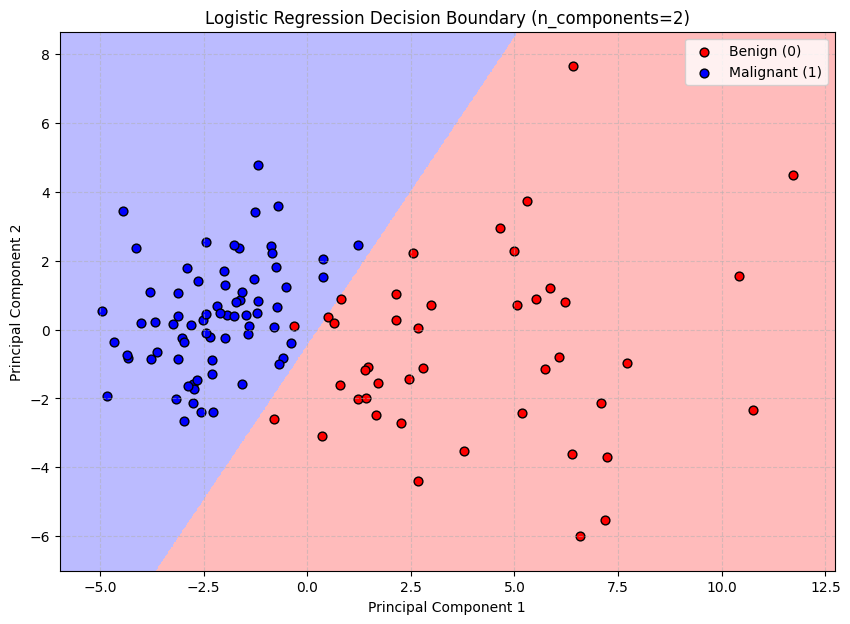

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# 1) Re-fit PCA and Model with n=2 for visualization
pca_2 = PCA(n_components=2)
X_train_pca2 = pca_2.fit_transform(X_train)
X_test_pca2 = pca_2.transform(X_test)

model_2 = LogisticRegression()
model_2.fit(X_train_pca2, y_train)

# 2) Create a meshgrid to plot the decision boundary
x_min, x_max = X_test_pca2[:, 0].min() - 1, X_test_pca2[:, 0].max() + 1
y_min, y_max = X_test_pca2[:, 1].min() - 1, X_test_pca2[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# 3) Predict across the entire meshgrid
Z = model_2.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# 4) Plotting
plt.figure(figsize=(10, 7))
cmap_light = ListedColormap(['#FFAAAA', '#AAAAFF'])
cmap_bold = ['#FF0000', '#0000FF']

plt.pcolormesh(xx, yy, Z, cmap=cmap_light, alpha=0.8)

# Plot the test points
for i, target_name in enumerate(['Benign (0)', 'Malignant (1)']):
    plt.scatter(X_test_pca2[y_test == i, 0], X_test_pca2[y_test == i, 1],
                c=cmap_bold[i], label=target_name, edgecolor='k', s=40)

plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Logistic Regression Decision Boundary (n_components=2)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()



---



### **2.3) Decision Trees**

The DT model starts by segmenting the data into 2 disjoint categories at the Root Node, on the basis of the feature which provides maximum information gain.

We will iterate over decision tree depths in the range of 1 to 7, to see which level provides the greatest accuracy and recall.

In [ ]:
from sklearn.metrics import accuracy_score, recall_score
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# We'll use a dictionary to store accuracy and recall for each depth
metrics_dict = {}

# Loop through max_depth values from 1 to 7
for depth in range(1, 8):
    print(f"\nTraining Decision Tree with max_depth={depth}:\n")
    dt_classifier = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_classifier.fit(X_train, y_train)

    # Make predictions on test set
    y_pred = dt_classifier.predict(X_test)

    # Get accuracy and recall, Store in metrics_dict
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred, pos_label=1)
    metrics_dict[depth] = [accuracy, recall]

    # Print metrics
    print(f"Accuracy: {accuracy * 100:.2f}%, Recall: {recall:.2f}")

print("\nMetrics Dictionary:")
print(metrics_dict)


Training Decision Tree with max_depth=1:

Accuracy: 89.47%, Recall: 0.89

Training Decision Tree with max_depth=2:

Accuracy: 92.98%, Recall: 0.97

Training Decision Tree with max_depth=3:

Accuracy: 94.74%, Recall: 0.97

Training Decision Tree with max_depth=4:

Accuracy: 94.74%, Recall: 0.96

Training Decision Tree with max_depth=5:

Accuracy: 94.74%, Recall: 0.96

Training Decision Tree with max_depth=6:

Accuracy: 93.86%, Recall: 0.96

Training Decision Tree with max_depth=7:

Accuracy: 94.74%, Recall: 0.96

Metrics Dictionary:
{1: [0.8947368421052632, 0.8873239436619719], 2: [0.9298245614035088, 0.971830985915493], 3: [0.9473684210526315, 0.971830985915493], 4: [0.9473684210526315, 0.9577464788732394], 5: [0.9473684210526315, 0.9577464788732394], 6: [0.9385964912280702, 0.9577464788732394], 7: [0.9473684210526315, 0.9577464788732394]}


- Using too few levels/splits (low depth) in a decision tree can lead to an overly simplistic model, which contributes to high bias and lower predictive accuracy due to underfitting.
- On the other hand, increased depth in decision trees increases model complexity, which typically reduces bias but significantly increases the risk of overfitting (high variance); this likely explains the drop in accuracy of predictions beyond 3 levels/splits.
- We see that the tree with `max_depth = 3` provides the maximum accuracy and recall. We will now plot this tree, and see which features provide maximum information gain at each level of the tree.

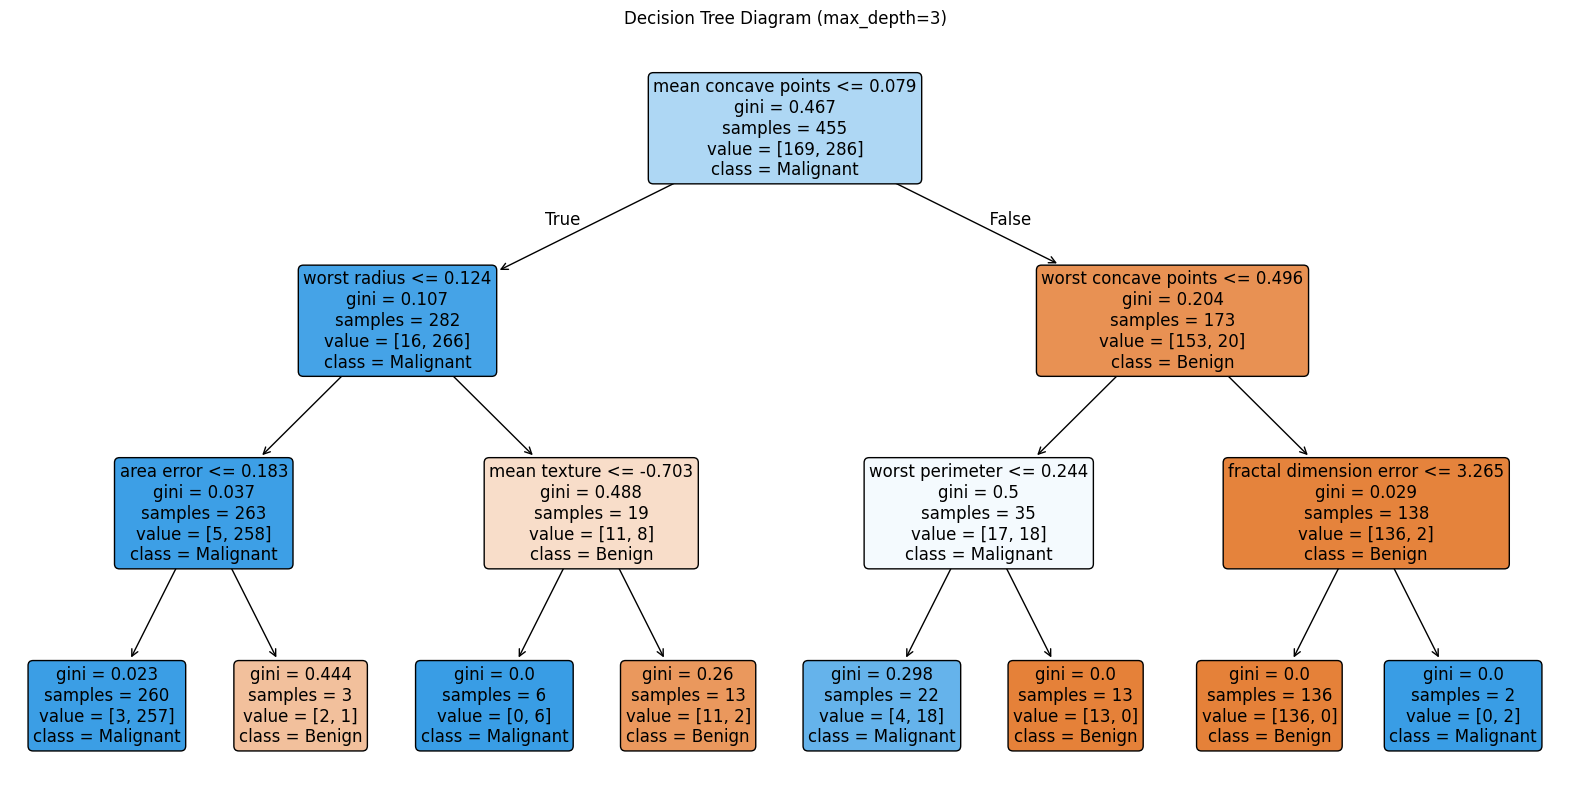

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# 1) Re-train the model specifically with max_depth=3
dt_depth_3 = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_depth_3.fit(X_train, y_train)

# 2) Plot the tree structure
plt.figure(figsize=(20, 10))
plot_tree(dt_depth_3,
          feature_names=X.columns,
          class_names=['Benign', 'Malignant'],
          filled=True,
          rounded=True,
          fontsize=12)

plt.title("Decision Tree Diagram (max_depth=3)")
plt.show()

- From the diagram above, we notice that the first feature split uses `mean concave points` , rather than metrics of tumor size, which follow thereafter to refine our classification.

- A lower value for `mean concave points` leads to further splits on size-features such as `worst radius` and `area error`, indicating that irregular shapes (concave points) and larger sizes (worst radius) are important indicators of malignancy.

### **2.4) Random Forest**

We now implement a Random Forest model and compare it with the performance of our depth=3 decision tree.

The Random Forest is an ensemble method, which builds several different decision trees and then takes the majority vote from predicted labels of each tree to generate the final prediction.

This uses two main techniques:
1. **Bagging** (Bootstrap Aggregating): It trains each tree on **a different random sample** of the data (with replacement).
2. **Feature Randomness**: At each split in a tree, it only considers a **random subset of the features**.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# 1) Initialize the Random Forest
# use n_estimators=100 different decision trees
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

# 2) Fit the model
rf_classifier.fit(X_train, y_train)

# 3) Predict and evaluate
y_pred_rf = rf_classifier.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {rf_accuracy * 100:.2f}%")
print(f"Random Forest Recall: {rf_recall:.2f}")

# Compare with our best single Decision Tree (depth=3)
print(f"Single Decision Tree (depth=3) Accuracy: {metrics_dict[3][0] * 100:.2f}%")

Random Forest Accuracy: 96.49%
Random Forest Recall: 0.99
Single Decision Tree (depth=3) Accuracy: 94.74%


We observe that the **Random Forest** provides higher accuracy (96.49%) compared to the single **Decision Tree** (94.74%). This improvement is due to the nature of **ensemble methods**, which can help reduce variance and provide better generalization.
-  While a single decision tree is prone to overfitting (high variance) by memorizing noise in the training data, Random Forest reduces this risk by averaging the results of many trees. Through ***Bagging*** (Bootstrap Aggregation), each tree in the "forest" is trained on a different random subset of the data, ensuring the trees are de-correlated and capture different patterns. The final classification is based on a majority vote, which typically yields a more robust and reliable prediction than any individual tree could achieve alone.

## **3) Summary of Model Performance**

This section summarizes the performance of the various classification models trained on the Breast Cancer Wisconsin dataset, evaluated primarily on Accuracy and Recall.

1.  **Logistic Regression with PCA (Optimal n=2 Components):**
    *   **Accuracy:** 99.12%
    *   **Recall:** 100.00% (for malignant class)
    *   This model demonstrated the highest performance, outperforming even the standard Logistic Regression. PCA effectively reduced dimensionality while retaining crucial information, suggesting that many original features might be redundant or noisy.

2.  **Logistic Regression (Standard Scaled):**
    *   **Accuracy:** 97.37%
    *   **Recall:** 99.00% (for malignant class)
    *   This model performed very well, especially after feature scaling. Its high recall is particularly valuable in medical diagnosis to minimize false negatives.

3.  **Random Forest:**
    *   **Accuracy:** 96.49%
    *   **Recall:** 99.00% (for malignant class)
    *   As an ensemble method, Random Forest showed better performance than a single Decision Tree, using bagging and feature randomness to reduce overfitting and improve generalization.

4.  **Decision Tree (max_depth=3):**
    *   **Accuracy:** 94.74%
    *   **Recall:** 97.00% (for malignant class)
    *   While providing the lowest accuracy among the four, the Decision Tree offers significant interpretability. We observed that 'mean concave points' was the primary split, highlighting the importance of shape features in diagnosis.


For this specific breast cancer classification task, the **Logistic Regression model combined with PCA (using 2 principal components)** achieved the best overall performance, with 99.12% accuracy and 100% recall for identifying malignant tumors.

Given the critical nature of correctly identifying malignant cases (minimizing false negatives), its perfect recall makes it the most suitable model for deployment.

 The significant role of 'mean concave points' and other shape features in decision-making was also evident, aligning with clinical understanding of cancer detection.